<a href="https://colab.research.google.com/github/mrdjango/image-reterieval/blob/main/notebooks/automatic_mask_generator_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

# Automatically generating object masks with SAM

Since SAM can efficiently process prompts, masks for the entire image can be generated by sampling a large number of prompts over an image. This method was used to generate the dataset SA-1B.

The class `SamAutomaticMaskGenerator` implements this capability. It works by sampling single-point input prompts in a grid over the image, from each of which SAM can predict multiple masks. Then, masks are filtered for quality and deduplicated using non-maximal suppression. Additional options allow for further improvement of mask quality and quantity, such as running prediction on multiple crops of the image or postprocessing masks to remove small disconnected regions and holes.

In [2]:
from IPython.display import display, HTML
display(HTML(
"""
<a target="_blank" href="https://colab.research.google.com/github/facebookresearch/segment-anything/blob/main/notebooks/automatic_mask_generator_example.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>
"""
))

## Environment Set-up

If running locally using jupyter, first install `segment_anything` in your environment using the [installation instructions](https://github.com/facebookresearch/segment-anything#installation) in the repository. If running from Google Colab, set `using_colab=True` below and run the cell. In Colab, be sure to select 'GPU' under 'Edit'->'Notebook Settings'->'Hardware accelerator'.

In [1]:
using_colab = True

In [2]:
if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/segment-anything.git'

    !mkdir images
    !wget -P images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/dog.jpg

    !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

PyTorch version: 2.8.0+cu126
Torchvision version: 0.23.0+cu126
CUDA is available: True
  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-9odm20f3
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-9odm20f3
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=a3302348c436055ce50358a1d2dffb229ffb98465b5ddb67305797b3b2932267
  Stored in directory: /tmp/pip-ephem-wheel-cache-qme96hrl/wheels/29/82/ff/04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully built segment_anything
--2025-09-27 14:46:52--  https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/dog.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com

## Set-up

In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2

In [4]:
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

## Example image

In [45]:
image = cv2.imread('capture_grid.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

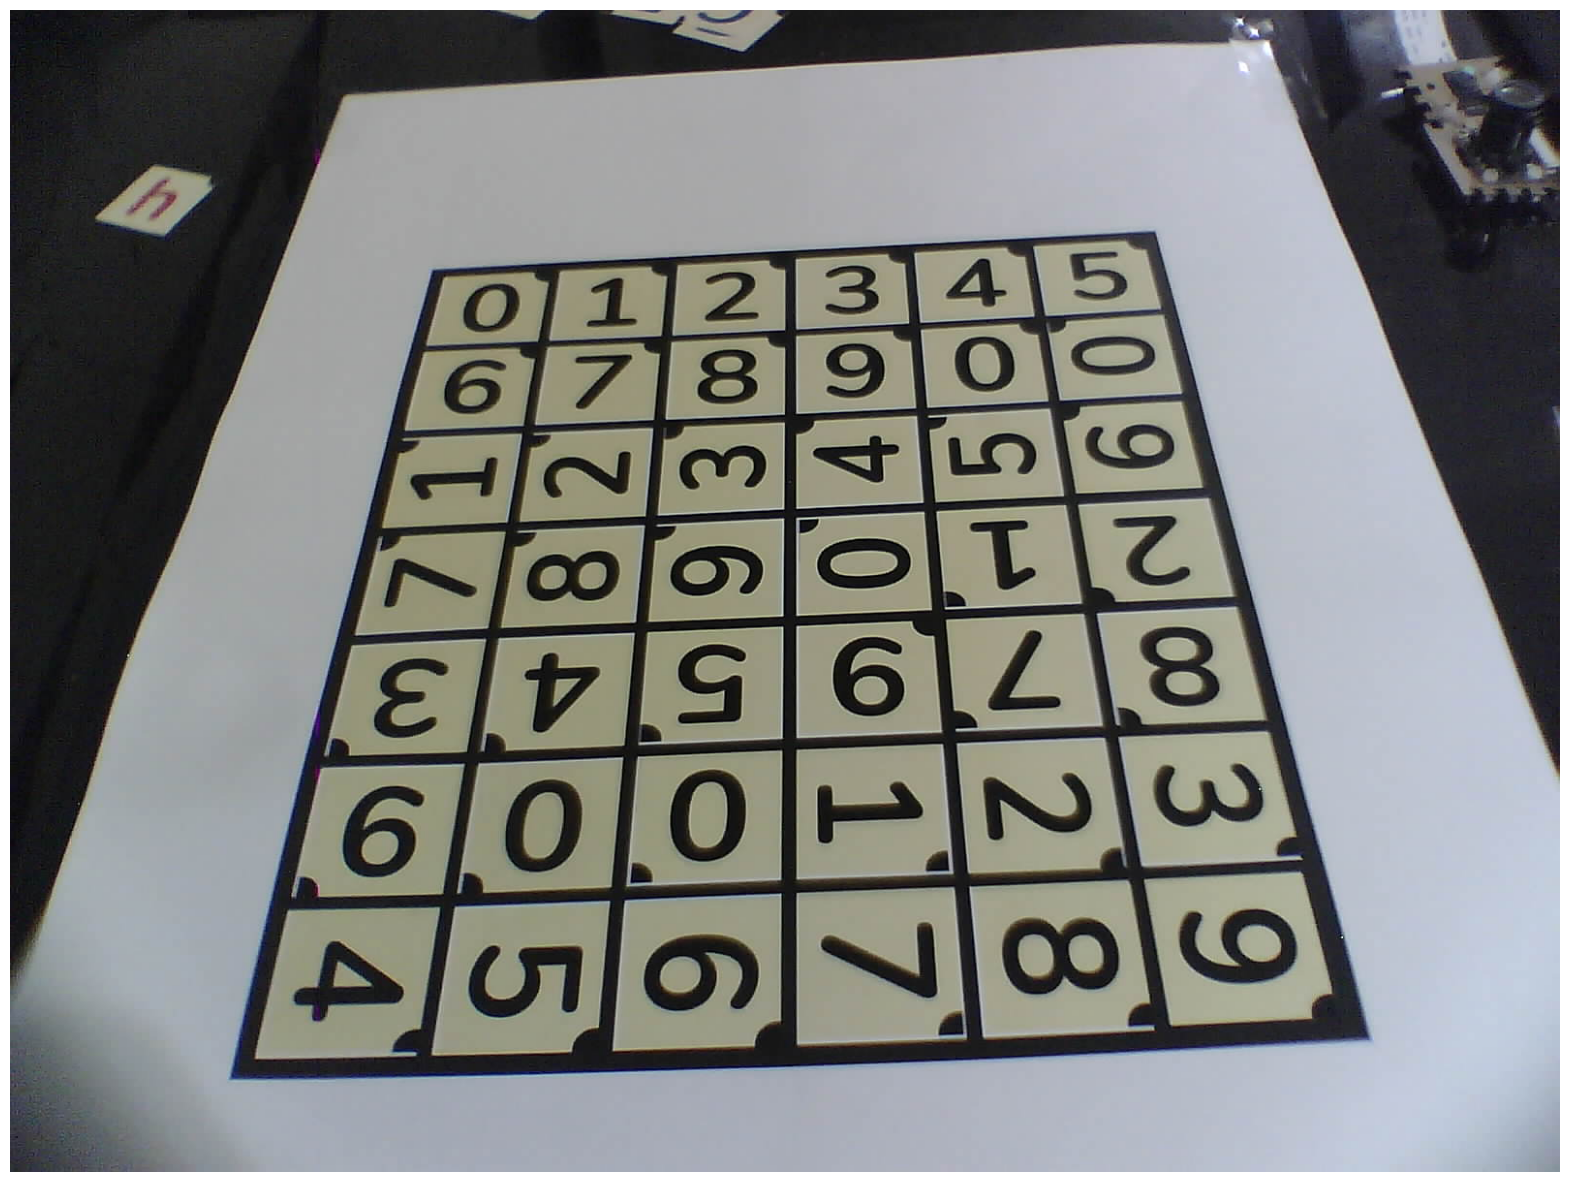

In [46]:
plt.figure(figsize=(20,20))
plt.imshow(image)
plt.axis('off')
plt.show()

## Automatic mask generation

To run automatic mask generation, provide a SAM model to the `SamAutomaticMaskGenerator` class. Set the path below to the SAM checkpoint. Running on CUDA and with the default model is recommended.

In [7]:
import sys
sys.path.append("..")
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"

device = "cuda"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

mask_generator = SamAutomaticMaskGenerator(sam)

To generate masks, just run `generate` on an image.

In [47]:
masks = mask_generator.generate(image)

Mask generation returns a list over masks, where each mask is a dictionary containing various data about the mask. These keys are:
* `segmentation` : the mask
* `area` : the area of the mask in pixels
* `bbox` : the boundary box of the mask in XYWH format
* `predicted_iou` : the model's own prediction for the quality of the mask
* `point_coords` : the sampled input point that generated this mask
* `stability_score` : an additional measure of mask quality
* `crop_box` : the crop of the image used to generate this mask in XYWH format

In [48]:
print(len(masks))
print(masks[0].keys())

149
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


Show all the masks overlayed on the image.

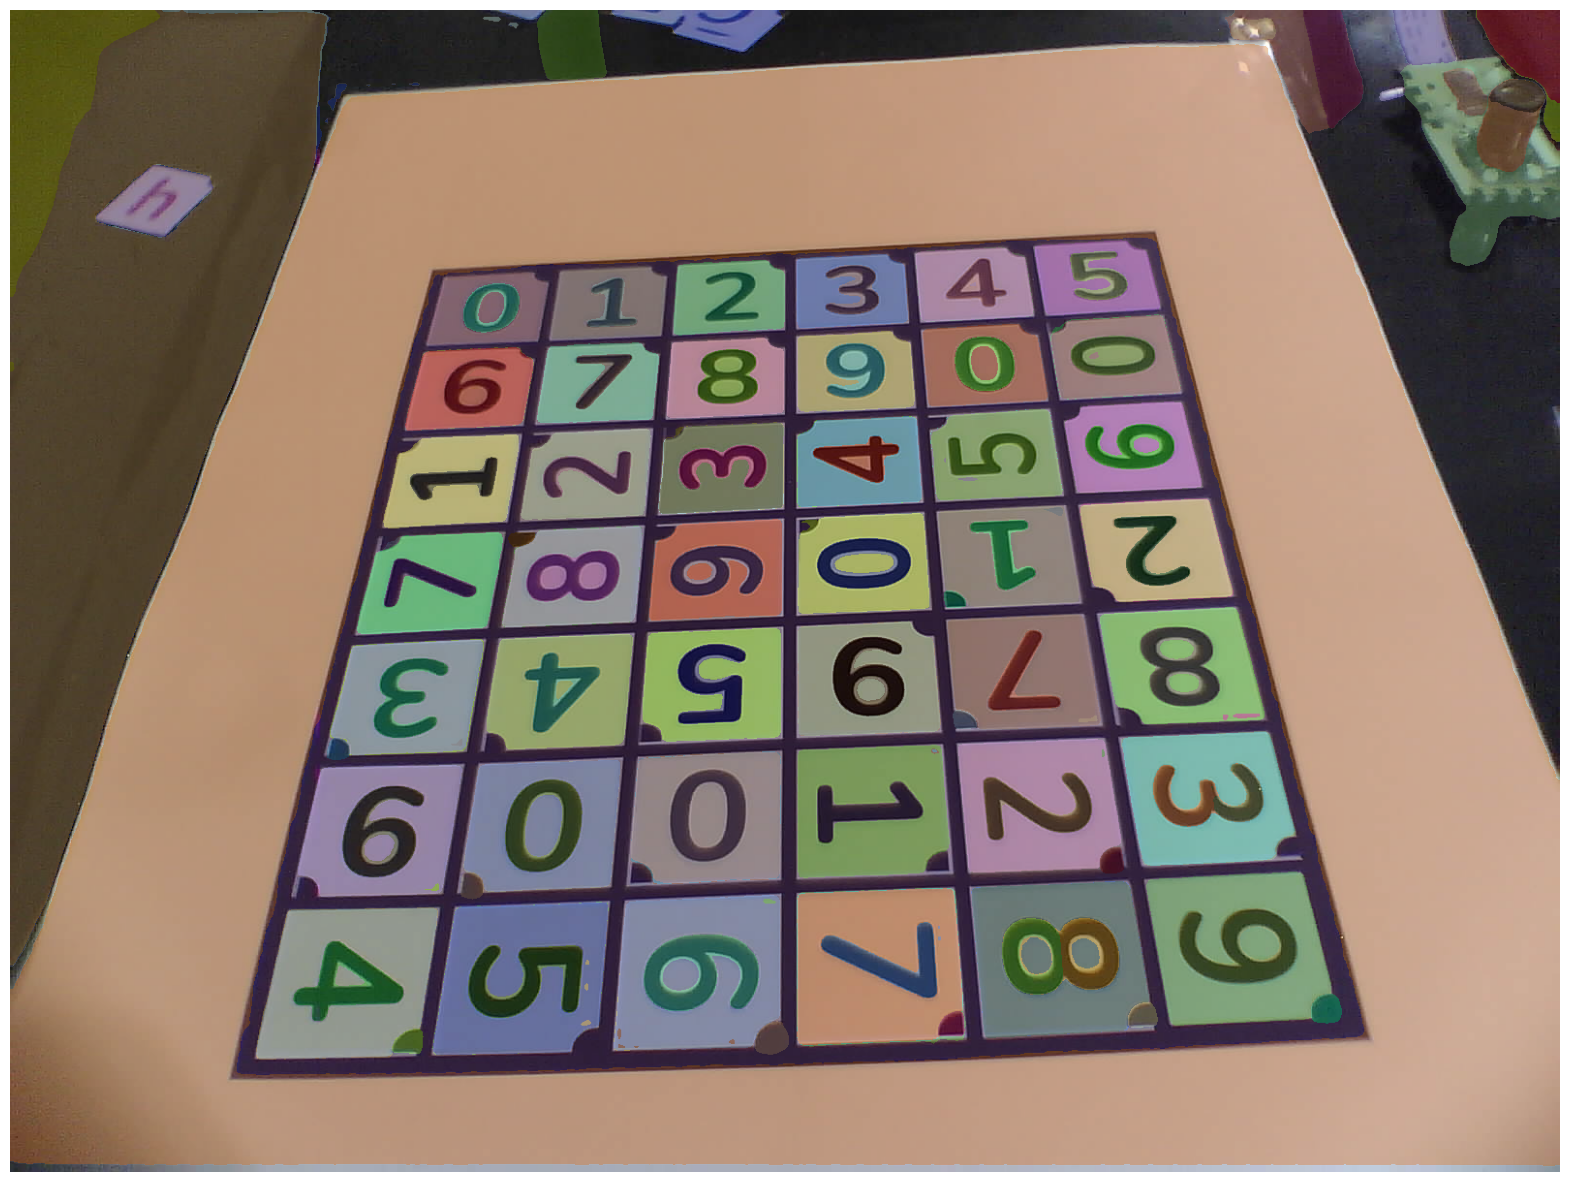

In [49]:
plt.figure(figsize=(20,20))
plt.imshow(image)
show_anns(masks)
plt.axis('off')
plt.show()

In [22]:
import numpy as np
import cv2

def get_object_corners(mask):
    # mask: boolean numpy array (H, W)
    mask = mask.astype(np.uint8) * 255

    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    # Get largest contour
    contour = max(contours, key=cv2.contourArea)

    # Convex hull
    hull = cv2.convexHull(contour)

    # Approximate polygon with 4 corners
    epsilon = 0.02 * cv2.arcLength(hull, True)  # tune 0.02 for precision
    approx = cv2.approxPolyDP(hull, epsilon, True)

    # If not 4 points, enforce 4 corners using minAreaRect
    if len(approx) != 4:
        rect = cv2.minAreaRect(contour)
        box = cv2.boxPoints(rect)  # 4 corners of rotated rectangle
        approx = np.int0(box)

    # Sort corners: top-left, top-right, bottom-right, bottom-left
    pts = approx.reshape(-1, 2)
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1)
    ordered = np.array([pts[np.argmin(s)],   # top-left
                        pts[np.argmin(diff)], # top-right
                        pts[np.argmax(s)],   # bottom-right
                        pts[np.argmax(diff)]]) # bottom-left

    return ordered

# Example usage:
corners = get_object_corners(masks[14]['segmentation'])
print("Corners:", corners)
if corners is not None:
    print("Top-left corner:", corners[0])
    print("Top-right corner:", corners[1])
    print("Bottom-right corner:", corners[2])
    print("Bottom-left corner:", corners[3])
    print("Width:", np.linalg.norm(corners[1] - corners[0]))
    print("Height:", np.linalg.norm(corners[3] - corners[0]))
    print("Center:", np.mean(corners, axis=0))

Corners: [[1118  763]
 [1272  756]
 [1304  889]
 [1142  896]]
Top-left corner: [1118  763]
Top-right corner: [1272  756]
Bottom-right corner: [1304  889]
Bottom-left corner: [1142  896]
Width: 154.1590088188167
Height: 135.14806694880988
Center: [1209.  826.]


## Automatic mask generation options

There are several tunable parameters in automatic mask generation that control how densely points are sampled and what the thresholds are for removing low quality or duplicate masks. Additionally, generation can be automatically run on crops of the image to get improved performance on smaller objects, and post-processing can remove stray pixels and holes. Here is an example configuration that samples more masks:

In [50]:
mask_generator_2 = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=100,  # Requires open-cv to run post-processing
)

In [51]:
masks2 = mask_generator_2.generate(image)

In [52]:
len(masks2)

144

In [53]:
# export masks to json
import json
with open('masks2.json', 'w') as f:
    json.dump(str(masks2), f)

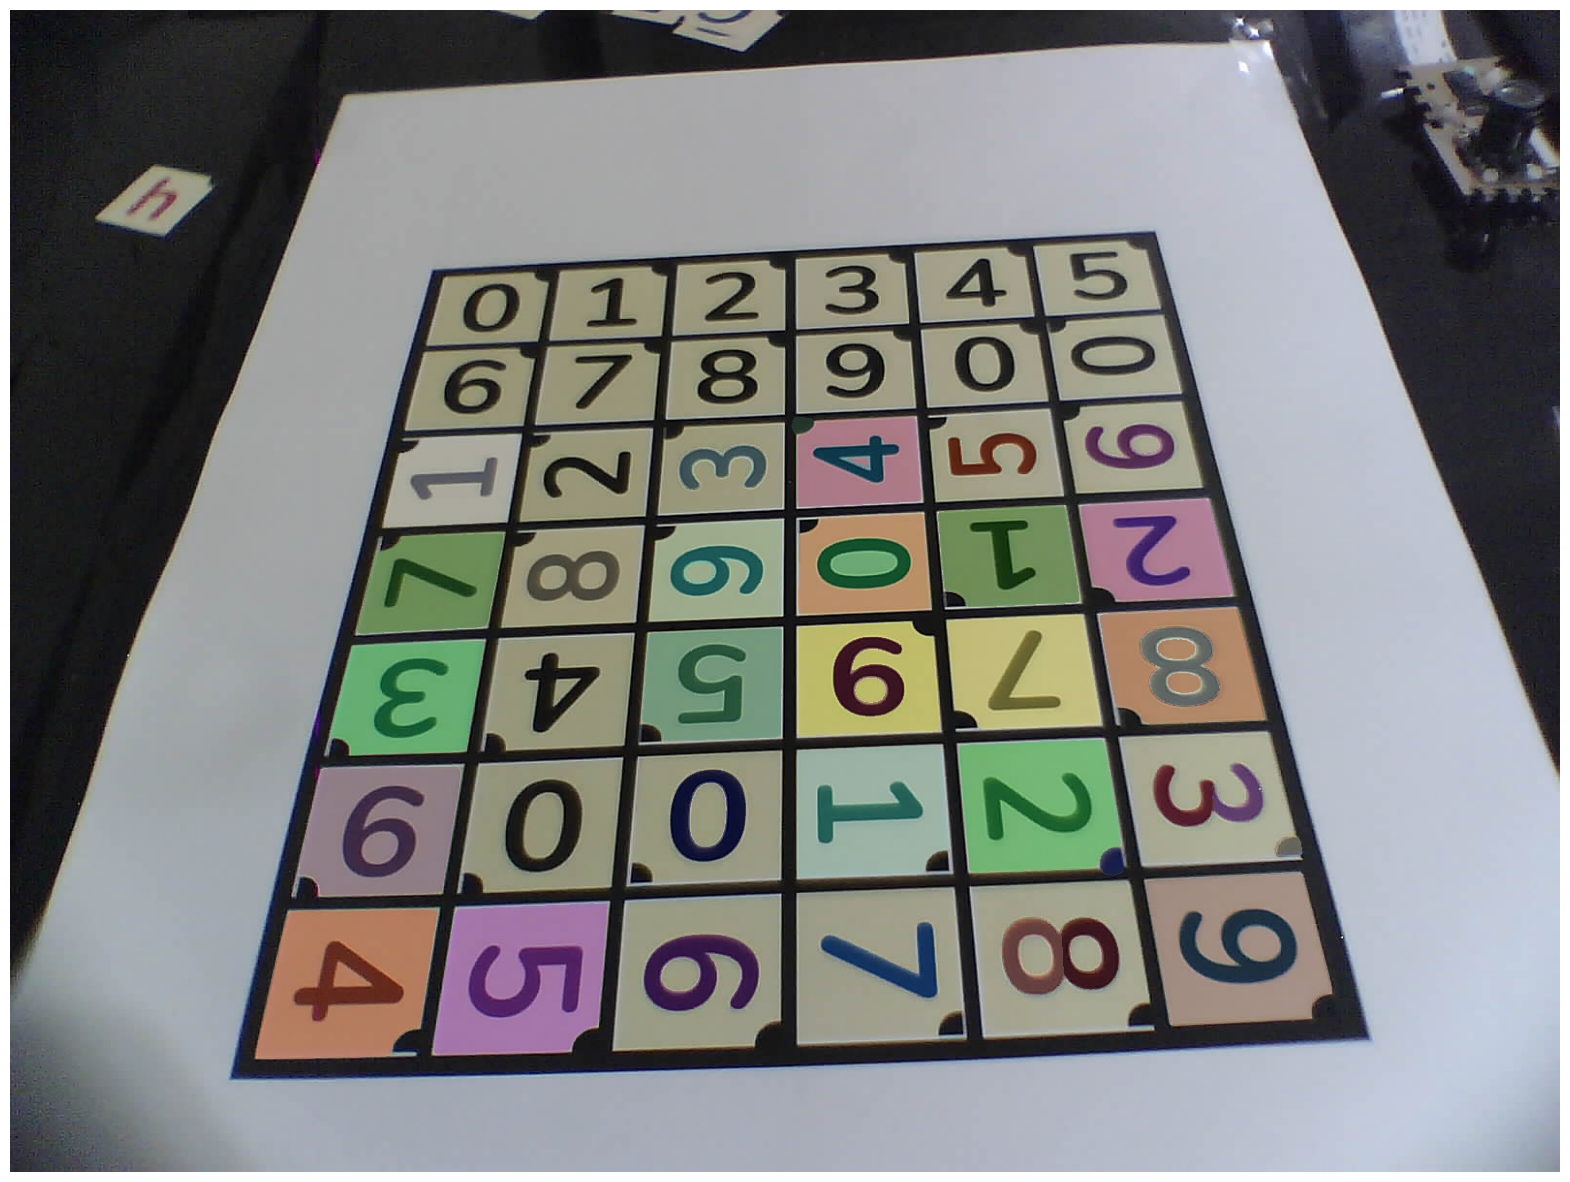

In [54]:
plt.figure(figsize=(20,20))
plt.imshow(image)
show_anns(masks2[:43])
plt.axis('off')
plt.show()

In [55]:
import numpy as np
import cv2
import os

# Assume `masks` is a list of dicts returned by sam_automatic_mask_generator.generate(image)
output_dir = "binary_masks"
os.makedirs(output_dir, exist_ok=True)

for i, mask_data in enumerate(masks):
    mask = mask_data["segmentation"]  # boolean mask
    binary_mask = (mask.astype(np.uint8) * 255)  # convert to 0 and 255
    cv2.imwrite(os.path.join(output_dir, f"mask_{i}.png"), binary_mask)


{'index': 0, 'area': 22307, 'bbox_xywh': [1118, 755, 187, 141], 'corners_xy': {'top_left': (1118, 755), 'top_right': (1305, 755), 'bottom_left': (1118, 896), 'bottom_right': (1305, 896)}}
{'index': 1, 'area': 27834, 'bbox_xywh': [769, 925, 178, 167], 'corners_xy': {'top_left': (769, 925), 'top_right': (947, 925), 'bottom_left': (769, 1092), 'bottom_right': (947, 1092)}}
{'index': 2, 'area': 28436, 'bbox_xywh': [1144, 907, 204, 168], 'corners_xy': {'top_left': (1144, 907), 'top_right': (1348, 907), 'bottom_left': (1144, 1075), 'bottom_right': (1348, 1075)}}
{'index': 3, 'area': 28350, 'bbox_xywh': [957, 916, 190, 168], 'corners_xy': {'top_left': (957, 916), 'top_right': (1147, 916), 'bottom_left': (957, 1084), 'bottom_right': (1147, 1084)}}
{'index': 4, 'area': 21862, 'bbox_xywh': [945, 763, 173, 141], 'corners_xy': {'top_left': (945, 763), 'top_right': (1118, 763), 'bottom_left': (945, 904), 'bottom_right': (1118, 904)}}


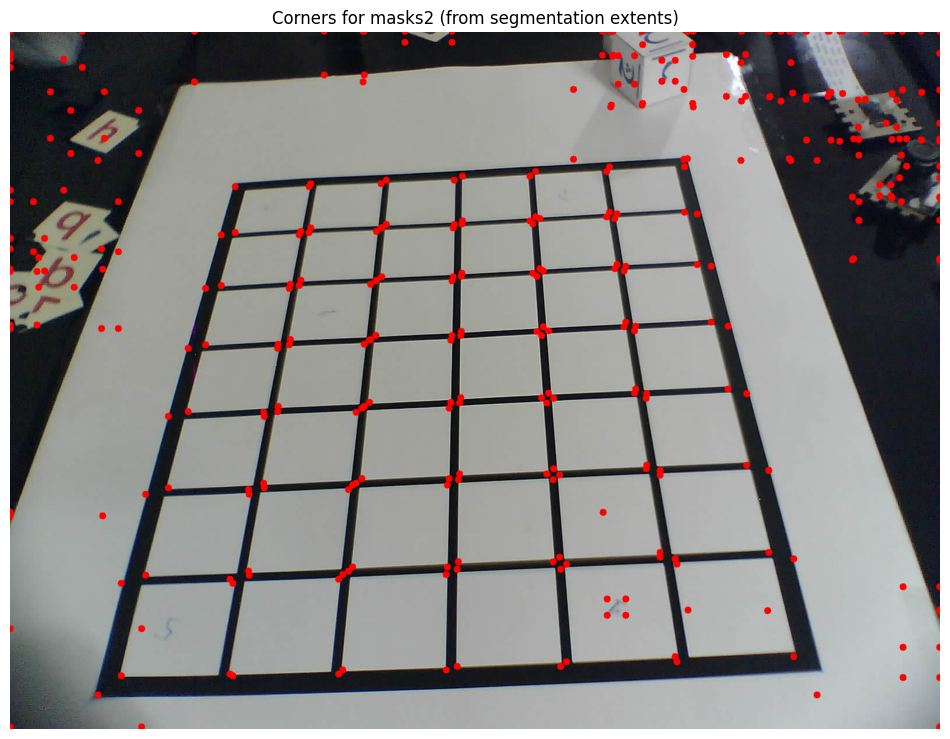

In [37]:
from typing import List, Dict, Tuple
import json
import numpy as np

# Contract
# Input: masks2 -> List[Dict] with keys 'bbox' (XYWH) and 'segmentation' (H x W boolean array)
# Output: corners_per_object -> List[Dict[str, List[Tuple[int,int]]]]

def clamp(v, lo, hi):
    return max(lo, min(int(v), hi))

img_h, img_w = image.shape[:2]
corners_per_object: List[Dict[str, List[Tuple[int,int]]]] = []

for idx, m in enumerate(masks2):
    # Prefer exact extents from the mask if available
    tl = tr = bl = br = None

    mask = m.get('segmentation', None)
    if mask is not None and isinstance(mask, np.ndarray) and mask.any():
        ys, xs = np.where(mask)
        x_min, x_max = xs.min(), xs.max()     # inclusive
        y_min, y_max = ys.min(), ys.max()     # inclusive
        tl = (clamp(x_min, 0, img_w-1), clamp(y_min, 0, img_h-1))
        tr = (clamp(x_max, 0, img_w-1), clamp(y_min, 0, img_h-1))
        bl = (clamp(x_min, 0, img_w-1), clamp(y_max, 0, img_h-1))
        br = (clamp(x_max, 0, img_w-1), clamp(y_max, 0, img_h-1))
    else:
        # Fall back to bbox (XYWH). Use inclusive bounds on right/bottom: x+w-1, y+h-1
        if 'bbox' not in m or m['bbox'] is None:
            continue
        x, y, w, h = m['bbox']
        x2 = x + w - 1
        y2 = y + h - 1
        tl = (clamp(x, 0, img_w-1), clamp(y, 0, img_h-1))
        tr = (clamp(x2, 0, img_w-1), clamp(y, 0, img_h-1))
        bl = (clamp(x, 0, img_w-1), clamp(y2, 0, img_h-1))
        br = (clamp(x2, 0, img_w-1), clamp(y2, 0, img_h-1))

    # Compose entry
    entry = {
        'index': idx,
        'area': int(m.get('area', 0)),
        'bbox_xywh': [int(v) for v in m.get('bbox', [0, 0, 0, 0])],
        'corners_xy': {
            'top_left': tl,
            'top_right': tr,
            'bottom_left': bl,
            'bottom_right': br,
        }
    }
    corners_per_object.append(entry)

# Preview first 5 entries
for row in corners_per_object[:5]:
    print(row)

# Optional: visualize corner points on image
show_preview = True
if show_preview:
    vis = image.copy()
    for row in corners_per_object:
        for p in row['corners_xy'].values():
            cv2.circle(vis, p, radius=6, color=(255,0,0), thickness=-1)
    plt.figure(figsize=(12,12))
    plt.imshow(vis)
    plt.title('Corners for masks2 (from segmentation extents)')
    plt.axis('off')
    plt.show()

# Optional: save to JSON
save_json = False
if save_json:
    with open('masks2_corners.json', 'w') as f:
        json.dump(corners_per_object, f)
    print('Saved masks2_corners.json with', len(corners_per_object), 'entries')

In [91]:
import cv2
import numpy as np

def sam_mask_to_convex_hull(sam_mask):
    """
    Convert a SAM binary mask to convex hull mask + hull points.

    Args:
        sam_mask: numpy array of shape (H, W) with True/False values.

    Returns:
        hull_mask: binary mask with convex hull filled in.
        hull_points: array of convex hull points (x,y).
    """
    # Ensure mask is uint8 [0,255]
    mask = (sam_mask.astype(np.uint8) * 255).copy()

    # find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    hull_points = []
    # make sure it's uint8 C-contiguous
    hull_mask = np.zeros(mask.shape, dtype=np.uint8)

    for cnt in contours:
        # compute convex hull
        hull = cv2.convexHull(cnt)
        hull_points.append(hull)
        # draw hull into a mask
        cv2.fillPoly(hull_mask, [hull], 255)

    return hull_mask.astype(bool), hull_points


# Example usage with your SAM dict
sam_output = masks2[13]

hull_mask, hull_pts = sam_mask_to_convex_hull(sam_output["segmentation"])

print("Convex Hull mask shape:", hull_mask.shape)
print("Convex Hull Points:", [pts.squeeze().tolist() for pts in hull_pts])


Convex Hull mask shape: (1200, 1600)
Convex Hull Points: [[[1075, 631], [1077, 633], [1078, 637], [1082, 660], [1084, 672], [1090, 711], [1093, 731], [1094, 739], [1094, 744], [1093, 746], [1090, 747], [1076, 748], [1058, 749], [1010, 751], [983, 752], [945, 752], [943, 750], [942, 745], [939, 710], [938, 697], [936, 670], [935, 656], [935, 639], [936, 638], [939, 637], [953, 636], [971, 635], [990, 634], [1010, 633], [1054, 631]]]


In [69]:
masks2[0]

{'segmentation': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]),
 'area': 22307,
 'bbox': [1118, 755, 187, 141],
 'predicted_iou': 1.0106151103973389,
 'point_coords': [[1129.375, 823.125]],
 'stability_score': 0.9890398979187012,
 'crop_box': [596, 396, 1004, 804]}

In [92]:
import cv2
import numpy as np

def convex_hull_to_equilateral_polygon(hull_points, n_sides=6):
    """
    Compute a regular n-gon (equilateral polygon) that spans the convex hull.

    Args:
        hull_points: np.array of shape (N,1,2) from cv2.convexHull
        n_sides: number of polygon sides (e.g. 4=square, 6=hexagon)

    Returns:
        vertices: np.array of polygon vertices (n_sides,2)
    """
    # Compute centroid
    M = cv2.moments(hull_points)
    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])
    center = np.array([cx, cy])

    # Compute max distance from centroid to hull
    dists = np.linalg.norm(hull_points.squeeze() - center, axis=1)
    R = dists.max()

    # Generate regular polygon vertices
    vertices = []
    for i in range(n_sides):
        angle = 2 * np.pi * i / n_sides
        x = cx + R * np.cos(angle)
        y = cy + R * np.sin(angle)
        vertices.append([x, y])
    return np.array(vertices, dtype=np.float32)


# Example usage
hull_pts = np.array([pts.squeeze().tolist() for pts in hull_pts][0])
square = convex_hull_to_equilateral_polygon(hull_pts, n_sides=4)
hexagon = convex_hull_to_equilateral_polygon(hull_pts, n_sides=6)

print("Spanning square vertices:", square)
print("Spanning hexagon vertices:", hexagon)


Spanning square vertices: [[1109.3499  692.    ]
 [1012.      789.3499]
 [ 914.6501  692.    ]
 [1012.      594.6501]]
Spanning hexagon vertices: [[1109.3499  692.    ]
 [1060.6749  776.3075]
 [ 963.3251  776.3075]
 [ 914.6501  692.    ]
 [ 963.3251  607.6925]
 [1060.6749  607.6925]]


In [66]:
import cv2
import numpy as np

def crop_and_warp_quadrilateral(image, quad_points, output_size=(64, 64)):
    """
    Crop a quadrilateral region from the image and warp it to a square.

    Args:
        image: input image (H, W, C)
        quad_points: np.array of shape (4,2) with quadrilateral corners
        output_size: tuple (w,h) of output image size

    Returns:
        warped: the warped quadrilateral as a square (output_size)
    """
    # Ensure numpy float32
    quad_points = np.array(quad_points, dtype=np.float32)

    # Order points consistently: top-left, top-right, bottom-right, bottom-left
    rect = order_points(quad_points)

    # Destination square coordinates
    dst = np.array([
        [0, 0],
        [output_size[0]-1, 0],
        [output_size[0]-1, output_size[1]-1],
        [0, output_size[1]-1]
    ], dtype=np.float32)

    # Compute perspective transform
    M = cv2.getPerspectiveTransform(rect, dst)

    # Warp the perspective
    warped = cv2.warpPerspective(image, M, output_size)
    return warped


def order_points(pts):
    """ Order quadrilateral points: top-left, top-right, bottom-right, bottom-left """
    rect = np.zeros((4, 2), dtype=np.float32)
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]   # top-left
    rect[2] = pts[np.argmax(s)]   # bottom-right

    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # top-right
    rect[3] = pts[np.argmax(diff)]  # bottom-left
    return rect



img = cv2.imread("capture_grid.jpg")  # your main image

# Example quadrilateral (from convex hull or n-gon)
quad = np.array([(352.18, 90.57)
, (1297.67, 38.33)
, (1594.50, 1193.00)
, (0.00, 1188.00)])

cropped_square = crop_and_warp_quadrilateral(img, quad, output_size=(64, 64))

cv2.imwrite("cropped_64x64.png", cropped_square)


True

In [59]:
import cv2
import numpy as np

def get_object_corners(mask):
    mask = mask.astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    contour = max(contours, key=cv2.contourArea)
    rect = cv2.minAreaRect(contour)
    box = cv2.boxPoints(rect)
    return box.astype(np.float32)

def crop_object_from_sam(image, mask, crop_box, output_size=64):
    x0, y0, w, h = crop_box
    # Crop the original image to SAM's crop
    crop_img = image[y0:y0+h, x0:x0+w]

    # Get corners in the crop coordinates
    corners = get_object_corners(mask)
    if corners is None:
        return None

    # Destination square
    dst_pts = np.array([[0, 0],
                        [output_size-1, 0],
                        [output_size-1, output_size-1],
                        [0, output_size-1]], dtype="float32")

    # Perspective transform from crop coordinates
    M = cv2.getPerspectiveTransform(corners, dst_pts)
    warped = cv2.warpPerspective(crop_img, M, (output_size, output_size))

    return warped

# Example:
image = cv2.imread("pure_grid.jpg")
cropped = crop_object_from_sam(image, masks[5]['segmentation'], masks[5]['crop_box'], output_size=64)
cv2.imwrite("cropped.png", cropped)


True

In [63]:
import cv2
import numpy as np

def get_accurate_corners_from_mask(binary_mask):
    """
    Get highly accurate corner coordinates from a binary mask of a quadrangle.

    Args:
        binary_mask: Binary image (0 and 255) where the quadrangle is white

    Returns:
        ordered_corners: List of 4 corners in order [top-left, top-right, bottom-right, bottom-left]
    """
    # Find contours in the binary mask
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        raise ValueError("No contours found in the binary mask")

    # Get the largest contour (assuming it's the quadrangle)
    largest_contour = max(contours, key=cv2.contourArea)

    # Method 1: Polygon approximation (most accurate for straight edges)
    epsilon = 0.02 * cv2.arcLength(largest_contour, True)
    approx = cv2.approxPolyDP(largest_contour, epsilon, True)

    # If we don't get exactly 4 points, try different approaches
    if len(approx) != 4:
        # Method 2: Convex hull + approximation
        hull = cv2.convexHull(largest_contour)
        epsilon = 0.02 * cv2.arcLength(hull, True)
        approx = cv2.approxPolyDP(hull, epsilon, True)

        # Method 3: If still not 4 points, use minimum area rectangle
        if len(approx) != 4:
            rect = cv2.minAreaRect(largest_contour)
            box = cv2.boxPoints(rect)
            approx = np.int0(box)

    # Ensure we have exactly 4 points
    if len(approx) != 4:
        # Use the 4 extreme points
        leftmost = tuple(largest_contour[largest_contour[:, :, 0].argmin()][0])
        rightmost = tuple(largest_contour[largest_contour[:, :, 0].argmax()][0])
        topmost = tuple(largest_contour[largest_contour[:, :, 1].argmin()][0])
        bottommost = tuple(largest_contour[largest_contour[:, :, 1].argmax()][0])

        # Approximate corners from extreme points
        approx = np.array([leftmost, topmost, rightmost, bottommost], dtype=np.float32)
        approx = approx.reshape(4, 1, 2)

    # Reshape to 4x2 array
    corners = approx.reshape(4, 2)

    # Order corners consistently: top-left, top-right, bottom-right, bottom-left
    return order_corners(corners)

def order_corners(corners):
    """Order corners in consistent order: TL, TR, BR, BL"""
    # Calculate center point
    center = np.mean(corners, axis=0)

    # Sort corners based on their angle relative to center
    vectors = corners - center
    angles = np.arctan2(vectors[:, 1], vectors[:, 0])

    # Sort by angle and reorder to start from top-left quadrant
    sorted_indices = np.argsort(angles)
    sorted_corners = corners[sorted_indices]

    # Find the index of the point that should be top-left (smallest x+y)
    sums = np.sum(sorted_corners, axis=1)
    tl_index = np.argmin(sums)

    # Reorder to start from top-left
    ordered = np.roll(sorted_corners, -tl_index, axis=0)

    return ordered.tolist()

def refine_corners_with_corner_detection(binary_mask, initial_corners, window_size=5):
    """
    Refine corner positions using corner detection for sub-pixel accuracy.
    """
    # Convert to grayscale if needed
    if len(binary_mask.shape) == 3:
        gray = cv2.cvtColor(binary_mask, cv2.COLOR_BGR2GRAY)
    else:
        gray = binary_mask

    # Convert to float32 for cornerSubPix
    gray_float = np.float32(gray)

    # Refine each corner
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
    corners_array = np.array(initial_corners, dtype=np.float32).reshape(-1, 1, 2)

    refined_corners = cv2.cornerSubPix(gray_float, corners_array, (window_size, window_size),
                                      (-1, -1), criteria)

    return refined_corners.reshape(4, 2).tolist()

In [71]:
def quadrangle_to_square_pipeline(binary_mask, output_size=500):
    """
    Complete pipeline: detect corners and transform to square.

    Args:
        binary_mask: Binary mask of the quadrangle
        output_size: Size of the output square image

    Returns:
        warped: Square image with corrected perspective
        corners: Detected corner coordinates
    """
    # Step 1: Get accurate corners
    corners = get_accurate_corners_from_mask(binary_mask)

    # Step 2: Refine corners for sub-pixel accuracy
    refined_corners = refine_corners_with_corner_detection(binary_mask, corners)

    # Step 3: Define destination points for square output
    dst_points = np.array([
        [0, 0], # TL
        [output_size - 1, 0], # TR
        [output_size - 1, output_size - 1], # BR
        [0, output_size - 1] # BL
    ], dtype=np.float32)

    # Step 4: Calculate perspective transform matrix
    transform_matrix = cv2.getPerspectiveTransform(
        np.array(refined_corners, dtype=np.float32),
        dst_points
    )

    # Step 5: Apply perspective transformation
    warped = cv2.warpPerspective(binary_mask, transform_matrix, (output_size, output_size))

    return warped, refined_corners


# Assuming you have your binary mask
binary_mask = cv2.imread("/content/binary_masks/mask_5.png", cv2.IMREAD_GRAYSCALE)

# Apply threshold to ensure binary
_, binary_mask = cv2.threshold(binary_mask, 127, 255, cv2.THRESH_BINARY)

# Get corners and transformed square
square_output, corners = quadrangle_to_square_pipeline(binary_mask)

print("Detected corners (x, y):")
for i, corner in enumerate(corners):
    print(f", ({corner[0]:.2f}, {corner[1]:.2f})")

# Visualize results
color_mask = cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2BGR)
for i, corner in enumerate(corners):
    x, y = int(corner[0]), int(corner[1])
    cv2.circle(color_mask, (x, y), 10, (0, 255, 0), -1)
    cv2.putText(color_mask, str(i+1), (x+10, y+10),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

cv2.imshow("Detected Corners", color_mask)
cv2.imshow("Perspective Corrected", square_output)
cv2.waitKey(0)
cv2.destroyAllWindows()

AttributeError: module 'numpy' has no attribute 'int0'